In [61]:
import pandas as pd

In [62]:
metadata_path = r"metadata.csv"
df = pd.read_csv(metadata_path, sep=";")
df.head()

,SUBJECT_ID,SOURCE_SUBJECT,DATASET,SEX,AGE,DIAGNOSIS,DIAGNOSIS_SUBTYPE,DISEASE_DURATION,SCANNER_ID,SCANNER_MANUFACTURER,SCANNER_TYPE,FIELD_STRENGTH,SEQUENCE,INVERSION_TIME,REPETITION_TIME,SITE,C_ABCD_SET,C_INSEL_STUDY,C_INSEL_EPI_LESIONAL,C_INSEL_EPI_LATERALITY
0,OAS30001_ses-d0129_run-01,OAS30001,OASIS3,F,65.503078,Cognitively normal,CDR-0,NaN,OASIS-35177,SIEMENS,TrioTim,3.0,GR_IR,1000.0,2400,NaN,NaN,NaN,NaN,NaN
1,OAS30001_ses-d0129_run-02,OAS30001,OASIS3,F,65.503078,Cognitively normal,CDR-0,NaN,OASIS-35177,SIEMENS,TrioTim,3.0,GR_IR,1000.0,2400,NaN,NaN,NaN,NaN,NaN
2,OAS30001_ses-d0757_run-01,OAS30001,OASIS3,F,67.222448,Cognitively normal,CDR-0,NaN,OASIS-35177,SIEMENS,TrioTim,3.0,GR_IR,1000.0,2400,NaN,NaN,NaN,NaN,NaN
3,OAS30001_ses-d0757_run-02,OAS30001,OASIS3,F,67.222448,Cognitively normal,CDR-0,NaN,OASIS-35177,SIEMENS,TrioTim,3.0,GR_IR,1000.0,2400,NaN,NaN,NaN,NaN,NaN
4,OAS30001_ses-d2430,OAS30001,OASIS3,F,71.802872,Cognitively normal,CDR-0,NaN,OASIS-51010,SIEMENS,Biograph_mMR,3.0,GR_IR,900.0,2300,NaN,NaN,NaN,NaN,NaN


In [63]:
print(df.shape)
print(df.columns)

(2643, 20)
Index(['SUBJECT_ID', 'SOURCE_SUBJECT', 'DATASET', 'SEX', 'AGE', 'DIAGNOSIS',
       'DIAGNOSIS_SUBTYPE', 'DISEASE_DURATION', 'SCANNER_ID',
       'SCANNER_MANUFACTURER', 'SCANNER_TYPE', 'FIELD_STRENGTH', 'SEQUENCE',
       'INVERSION_TIME', 'REPETITION_TIME', 'SITE', 'C_ABCD_SET',
       'C_INSEL_STUDY', 'C_INSEL_EPI_LESIONAL', 'C_INSEL_EPI_LATERALITY'],
      dtype='object')


In [64]:
important_cols = ["SUBJECT_ID", "AGE", "DIAGNOSIS", "DIAGNOSIS_SUBTYPE"]
df[important_cols].isnull().sum()

SUBJECT_ID           0
AGE                  0
DIAGNOSIS            4
DIAGNOSIS_SUBTYPE    0
dtype: int64

In [65]:
df_clean = df.dropna(subset=important_cols).copy()

In [66]:
df_clean = df_clean[
    (df_clean["AGE"] >= 60) &
    (df_clean["AGE"] <= 85)
]

In [67]:
df_clean = df_clean[
    df_clean["DIAGNOSIS_SUBTYPE"] != "CDR-0.5"
]

In [68]:
df_clean["label"] = df_clean["DIAGNOSIS_SUBTYPE"].apply(
    lambda x: "normal" if x == "CDR-0" else "dementia"
)

In [69]:
final_df = df_clean[
    [
        "SUBJECT_ID",
        "SOURCE_SUBJECT",
        "SEX",
        "AGE",
        "DIAGNOSIS",
        "DIAGNOSIS_SUBTYPE",
        "label"
    ]
]

In [70]:
final_df.head()
final_df["label"].value_counts()

label
normal      1585
dementia     178
Name: count, dtype: int64

In [71]:
final_df.to_csv("clean_metadata.csv", index=False)

In [72]:
final_df.shape

(1763, 7)

In [73]:
import os

mri_base_path = r"D:\extracted_deep_learning\DLDiReCT_results\DL+DiReCT_results"

In [74]:
mri_folders = os.listdir(mri_base_path)

print(len(mri_folders))
print(mri_folders[:5])

2660
['OAS30001_ses-d0129_run-01', 'OAS30001_ses-d0129_run-02', 'OAS30001_ses-d0757_run-01', 'OAS30001_ses-d0757_run-02', 'OAS30001_ses-d2430']


In [75]:
# keeps only rows where MRI folder exists
matched_df = final_df[
    final_df["SUBJECT_ID"].isin(mri_folders)
].copy()

print("Before:", len(final_df))
print("After:", len(matched_df))

Before: 1763
After: 1763


In [76]:
matched_df.to_csv("matched_metadata.csv", index=False)

In [77]:
valid_rows = []

for _, row in matched_df.iterrows():
    folder_name = row["SUBJECT_ID"]
    folder_path = os.path.join(mri_base_path, folder_name)

    if os.path.exists(folder_path):
        files = os.listdir(folder_path)

        # check if correct MRI exists
        if any("T1w_norm_noskull" in f for f in files):
            valid_rows.append(row)

final_dataset = pd.DataFrame(valid_rows)

print("Final dataset size:", len(final_dataset))

Final dataset size: 1763


In [78]:
final_dataset.to_csv("final_dataset.csv", index=False)

In [79]:
matched_df.shape

(1763, 7)

In [80]:
final_dataset.shape

(1763, 7)

In [81]:
final_dataset["label"].value_counts()

label
normal      1585
dementia     178
Name: count, dtype: int64

In [82]:
import re
import pandas as pd

def get_session_number(subject_id):
    match = re.search(r"ses-d(\d+)", subject_id)
    return int(match.group(1)) if match else 999999

def get_run_priority(subject_id):
    if "run-01" in subject_id:
        return 1
    elif "run-02" in subject_id:
        return 2
    else:
        return 3

# Add sorting helpers
df_clean["session_num"] = df_clean["SUBJECT_ID"].apply(get_session_number)
df_clean["run_priority"] = df_clean["SUBJECT_ID"].apply(get_run_priority)

# Sort so earliest session + run-01 comes first
df_sorted = df_clean.sort_values(
    by=["SOURCE_SUBJECT", "session_num", "run_priority"]
)

# Keep only ONE scan per subject
one_scan_per_subject = df_sorted.groupby("SOURCE_SUBJECT").first().reset_index()

# Check class counts after removing repeated scans
one_scan_per_subject["label"].value_counts()

label
normal      607
dementia    108
Name: count, dtype: int64

In [83]:
print(one_scan_per_subject.shape)
print(one_scan_per_subject["label"].value_counts())

(715, 23)
label
normal      607
dementia    108
Name: count, dtype: int64


In [84]:

import os
import pandas as pd
from tqdm import tqdm

mri_base_path = r"D:\extracted_deep_learning\DLDiReCT_results\DL+DiReCT_results"

valid_rows = []

for _, row in tqdm(one_scan_per_subject.iterrows(), total=len(one_scan_per_subject)):
    folder_name = row["SUBJECT_ID"]

    nifti_path = os.path.join(
        mri_base_path,
        folder_name,
        "T1w_norm_noskull.nii.gz"
    )

    if os.path.exists(nifti_path):
        row = row.copy()
        row["nifti_path"] = nifti_path
        valid_rows.append(row)
    else:
        print("Missing:", folder_name)

matched_with_paths = pd.DataFrame(valid_rows)

print("Subjects with MRI files:", matched_with_paths.shape)
print(matched_with_paths["label"].value_counts())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 715/715 [00:04<00:00, 145.27it/s]


Subjects with MRI files: (715, 24)
label
normal      607
dementia    108
Name: count, dtype: int64


In [85]:
import nibabel as nib
import numpy as np

def count_informative_slices(nifti_path, axis=0, min_nonzero_ratio=0.03):
    img = nib.load(nifti_path)
    data = img.get_fdata()

    useful_count = 0

    for i in range(data.shape[axis]):
        if axis == 0:
            slice_data = data[i, :, :]
        elif axis == 1:
            slice_data = data[:, i, :]
        else:
            slice_data = data[:, :, i]

        nonzero_ratio = np.count_nonzero(slice_data) / slice_data.size

        if nonzero_ratio >= min_nonzero_ratio:
            useful_count += 1

    return useful_count

In [86]:
from tqdm import tqdm

slice_quality = []

for _, row in tqdm(matched_with_paths.iterrows(), total=len(matched_with_paths)):
    useful_count = count_informative_slices(
        row["nifti_path"],
        axis=1
    )

    slice_quality.append({
        "SUBJECT_ID": row["SUBJECT_ID"],
        "label": row["label"],
        "useful_slices": useful_count
    })

slice_quality_df = pd.DataFrame(slice_quality)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 715/715 [03:13<00:00,  3.70it/s]


In [87]:
print(slice_quality_df["useful_slices"].describe())
print(slice_quality_df["useful_slices"].value_counts().sort_index())

count    715.000000
mean     123.737063
std        5.874334
min      103.000000
25%      120.000000
50%      124.000000
75%      128.000000
max      143.000000
Name: useful_slices, dtype: float64
useful_slices
103     1
105     3
106     1
108     2
109     4
110     1
111     2
112     2
113     6
114    13
115    17
116    14
117    31
118    30
119    29
120    50
121    47
122    50
123    54
124    40
125    52
126    42
127    33
128    45
129    40
130    22
131    14
132    21
133    14
134    12
135     8
136     3
137     4
138     2
139     2
140     1
141     2
143     1
Name: count, dtype: int64


In [88]:
axis=0
for axis in [0, 1, 2]:
    test_counts = []

    for _, row in tqdm(matched_with_paths.head(20).iterrows(), total=20):
        useful_count = count_informative_slices(
            row["nifti_path"],
            axis=axis
        )
        test_counts.append(useful_count)

    print("Axis:", axis)
    print(pd.Series(test_counts).describe())

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.65it/s]


Axis: 0
count     20.000000
mean     125.000000
std        5.251566
min      118.000000
25%      120.750000
50%      124.500000
75%      128.500000
max      138.000000
dtype: float64


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  6.43it/s]


Axis: 1
count     20.000000
mean     124.100000
std        5.457009
min      115.000000
25%      122.750000
50%      124.000000
75%      128.000000
max      134.000000
dtype: float64


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  6.60it/s]

Axis: 2
count     20.000000
mean     158.100000
std        7.047956
min      146.000000
25%      154.000000
50%      158.500000
75%      160.000000
max      178.000000
dtype: float64


Shape: (176, 256, 256)


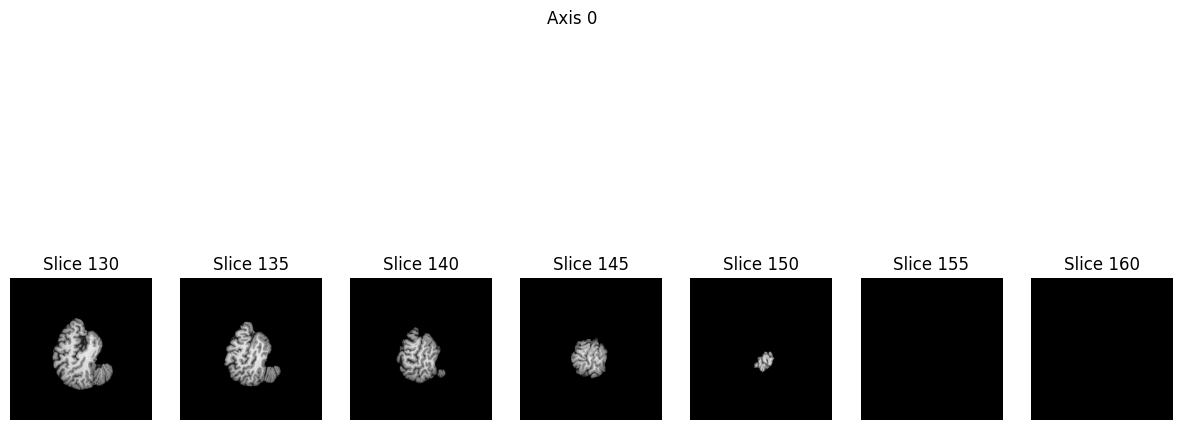

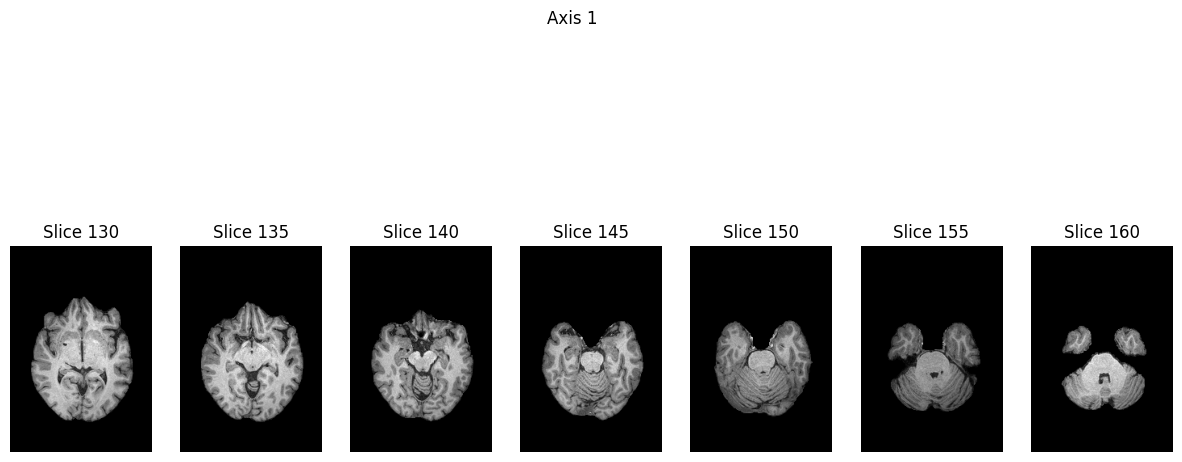

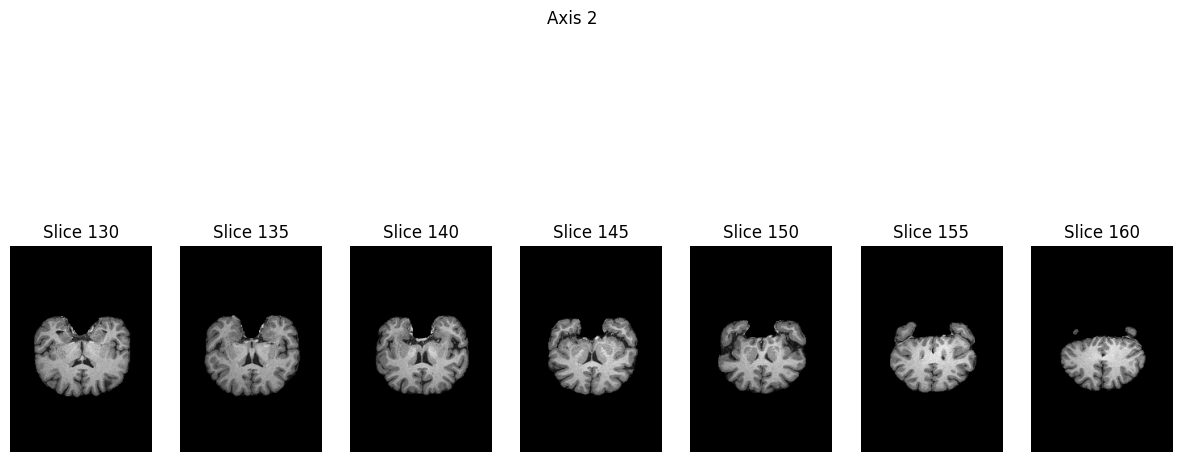

In [89]:
import matplotlib.pyplot as plt
import nibabel as nib

row = matched_with_paths.iloc[0]
data = nib.load(row["nifti_path"]).get_fdata()

print("Shape:", data.shape)

slice_indices = [130, 135, 140, 145, 150, 155, 160]

for axis in [0, 1, 2]:
    fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 7))
    fig.suptitle(f"Axis {axis}")

    for ax, idx in zip(axes, slice_indices):
        if axis == 0:
            slice_data = data[idx, :, :]
        elif axis == 1:
            slice_data = data[:, idx, :]
        else:
            slice_data = data[:, :, idx]

        ax.imshow(slice_data.T, cmap="gray", origin="lower")
        ax.set_title(f"Slice {idx}")
        ax.axis("off")

    plt.show()

In [90]:
slice_quality = []

for _, row in tqdm(matched_with_paths.iterrows(), total=len(matched_with_paths)):
    useful_count = count_informative_slices(
        row["nifti_path"],
        axis=1
    )

    slice_quality.append({
        "SUBJECT_ID": row["SUBJECT_ID"],
        "SOURCE_SUBJECT": row["SOURCE_SUBJECT"],
        "label": row["label"],
        "useful_slices": useful_count,
        "DIAGNOSIS": row["DIAGNOSIS"],
        "DIAGNOSIS_SUBTYPE": row["DIAGNOSIS_SUBTYPE"],
        "nifti_path": row["nifti_path"]
    })

slice_quality_df = pd.DataFrame(slice_quality)

print(slice_quality_df["useful_slices"].describe())
print(slice_quality_df.groupby("label")["useful_slices"].describe())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 715/715 [03:14<00:00,  3.67it/s]

count    715.000000
mean     123.737063
std        5.874334
min      103.000000
25%      120.000000
50%      124.000000
75%      128.000000
max      143.000000
Name: useful_slices, dtype: float64
          count        mean       std    min    25%    50%    75%    max
label                                                                   
dementia  108.0  124.351852  5.770234  108.0  120.0  125.0  128.0  141.0
normal    607.0  123.627677  5.890622  103.0  120.0  123.0  128.0  143.0


In [91]:
slice_quality_df["useful_slices"].min()

np.int64(103)

In [92]:
print(slice_quality_df.columns)
print(slice_quality_df["label"].value_counts())
print(slice_quality_df[["SUBJECT_ID", "SOURCE_SUBJECT", "label", "useful_slices"]].head())
print("Duplicate SOURCE_SUBJECT:", slice_quality_df["SOURCE_SUBJECT"].duplicated().sum())
print("Duplicate SUBJECT_ID:", slice_quality_df["SUBJECT_ID"].duplicated().sum())

Index(['SUBJECT_ID', 'SOURCE_SUBJECT', 'label', 'useful_slices', 'DIAGNOSIS',
       'DIAGNOSIS_SUBTYPE', 'nifti_path'],
      dtype='object')
label
normal      607
dementia    108
Name: count, dtype: int64
                  SUBJECT_ID SOURCE_SUBJECT   label  useful_slices
0  OAS30001_ses-d0129_run-01       OAS30001  normal            116
1         OAS30002_ses-d0371       OAS30002  normal            134
2  OAS30003_ses-d0558_run-01       OAS30003  normal            123
3  OAS30004_ses-d2229_run-01       OAS30004  normal            129
4         OAS30006_ses-d0166       OAS30006  normal            134
Duplicate SOURCE_SUBJECT: 0
Duplicate SUBJECT_ID: 0


In [93]:
import pandas as pd

# Check class counts first
print(slice_quality_df["label"].value_counts())

normal_subjects = (
    slice_quality_df[slice_quality_df["label"] == "normal"]
    .sort_values("useful_slices", ascending=False)
    .head(100)
)

dementia_subjects = (
    slice_quality_df[slice_quality_df["label"] == "dementia"]
    .sort_values("useful_slices", ascending=False)
    .head(100)
)

final_selected_200 = pd.concat(
    [normal_subjects, dementia_subjects],
    ignore_index=True
)

final_selected_200 = final_selected_200.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(final_selected_200["label"].value_counts())
print(final_selected_200.shape)

final_selected_200.to_csv("final_selected_200_axis1_subjects.csv", index=False)

label
normal      607
dementia    108
Name: count, dtype: int64
label
normal      100
dementia    100
Name: count, dtype: int64
(200, 7)


In [94]:
final_selected_200_clean = final_selected_200.drop(
    columns=["nifti_path"],
    errors="ignore"
)

final_selected_200_clean.to_csv(
    "final_selected_200_axis1_subjects_clean.csv",
    index=False
)

In [103]:
import os
import shutil
import numpy as np
import nibabel as nib
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

output_base = r"D:\processed_oasis_axis1_train_val_clean"

# optional: remove old wrong folder first
if os.path.exists(output_base):
    shutil.rmtree(output_base)

train_df, val_df = train_test_split(
    final_selected_200,
    test_size=0.2,
    stratify=final_selected_200["label"],
    random_state=42
)

def brain_content_score(slice_data):
    threshold = np.percentile(slice_data, 60)
    return np.sum(slice_data > threshold)

def select_top_axis1_slices(data, num_slices=100):
    scores = []

    for idx in range(data.shape[1]):
        slice_data = data[:, idx, :]
        score = brain_content_score(slice_data)
        scores.append((idx, score))

    best = sorted(scores, key=lambda x: x[1], reverse=True)[:num_slices]
    selected_indices = sorted([idx for idx, score in best])

    return selected_indices

def save_axis1_slices(df, split_name):
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extracting {split_name}"):
        subject = row["SOURCE_SUBJECT"]
        label = row["label"]
        nifti_path = row["nifti_path"]

        data = nib.load(nifti_path).get_fdata()

        selected_indices = select_top_axis1_slices(data, num_slices=100)

        save_dir = os.path.join(output_base, split_name, label, subject)
        os.makedirs(save_dir, exist_ok=True)

        for idx in selected_indices:
            slice_data = data[:, idx, :]

            slice_min = np.min(slice_data)
            slice_max = np.max(slice_data)

            if slice_max > slice_min:
                slice_data = (slice_data - slice_min) / (slice_max - slice_min)
            else:
                slice_data = np.zeros_like(slice_data)

            slice_data = (slice_data * 255).astype(np.uint8)

            img = Image.fromarray(slice_data.T)
            img.save(os.path.join(save_dir, f"{subject}_axis1_slice_{idx:03d}.png"))

In [104]:
save_axis1_slices(train_df, "train")
save_axis1_slices(val_df, "val")

Extracting val: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:40<00:00,  1.01s/it]


In [105]:
import os

for split in ["train", "val"]:
    for label in ["normal", "dementia"]:
        path = os.path.join(output_base, split, label)
        subjects = os.listdir(path)

        total_images = sum(
            len([f for f in os.listdir(os.path.join(path, subject)) if f.endswith(".png")])
            for subject in subjects
        )

        print(split, label, "subjects:", len(subjects), "images:", total_images)

train normal subjects: 80 images: 8000
train dementia subjects: 80 images: 8000
val normal subjects: 20 images: 2000
val dementia subjects: 20 images: 2000


In [106]:
import os
import pandas as pd

manifest_records = []

for split_name, df in [("train", train_df), ("val", val_df)]:
    for _, row in df.iterrows():
        subject = row["SOURCE_SUBJECT"]
        label = row["label"]

        subject_path = os.path.join(output_base, split_name, label, subject)

        num_images = len([
            f for f in os.listdir(subject_path)
            if f.endswith(".png")
        ])

        manifest_records.append({
            "split": split_name,
            "SUBJECT_ID": row["SUBJECT_ID"],
            "SOURCE_SUBJECT": row["SOURCE_SUBJECT"],
            "label": row["label"],
            "DIAGNOSIS": row["DIAGNOSIS"],
            "DIAGNOSIS_SUBTYPE": row["DIAGNOSIS_SUBTYPE"],
            "useful_slices": row["useful_slices"],
            "num_images": num_images
        })

axis1_manifest = pd.DataFrame(manifest_records)

axis1_manifest.to_csv(
    "axis1_final_train_val_manifest.csv",
    index=False
)

axis1_manifest.head()

,split,SUBJECT_ID,SOURCE_SUBJECT,label,DIAGNOSIS,DIAGNOSIS_SUBTYPE,useful_slices,num_images
0,train,OAS31123_ses-d0078,OAS31123,dementia,AD Dementia,CDR-2,126,100
1,train,OAS30092_ses-d0636,OAS30092,normal,Cognitively normal,CDR-0,130,100
2,train,OAS30397_ses-d0043,OAS30397,dementia,AD Dementia,CDR-1,121,100
3,train,OAS31131_ses-d0101,OAS31131,normal,Cognitively normal,CDR-0,129,100
4,train,OAS30174_ses-d0582_run-01,OAS30174,normal,Cognitively normal,CDR-0,132,100
